<a href="https://colab.research.google.com/github/Muqqadas30/CodeAlpha_ML_Internship_Tasks/blob/main/task4/task4_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               classification_report, roc_curve)

np.random.seed(42)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

df = X.copy()
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


target
1    357
0    212
Name: count, dtype: int64


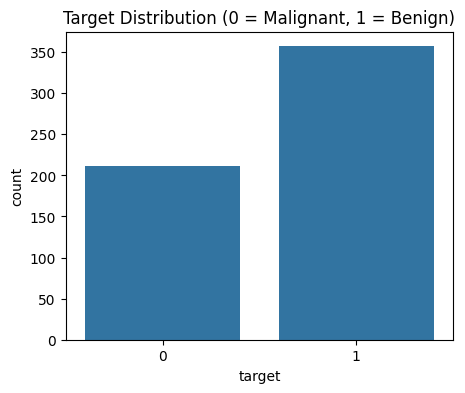

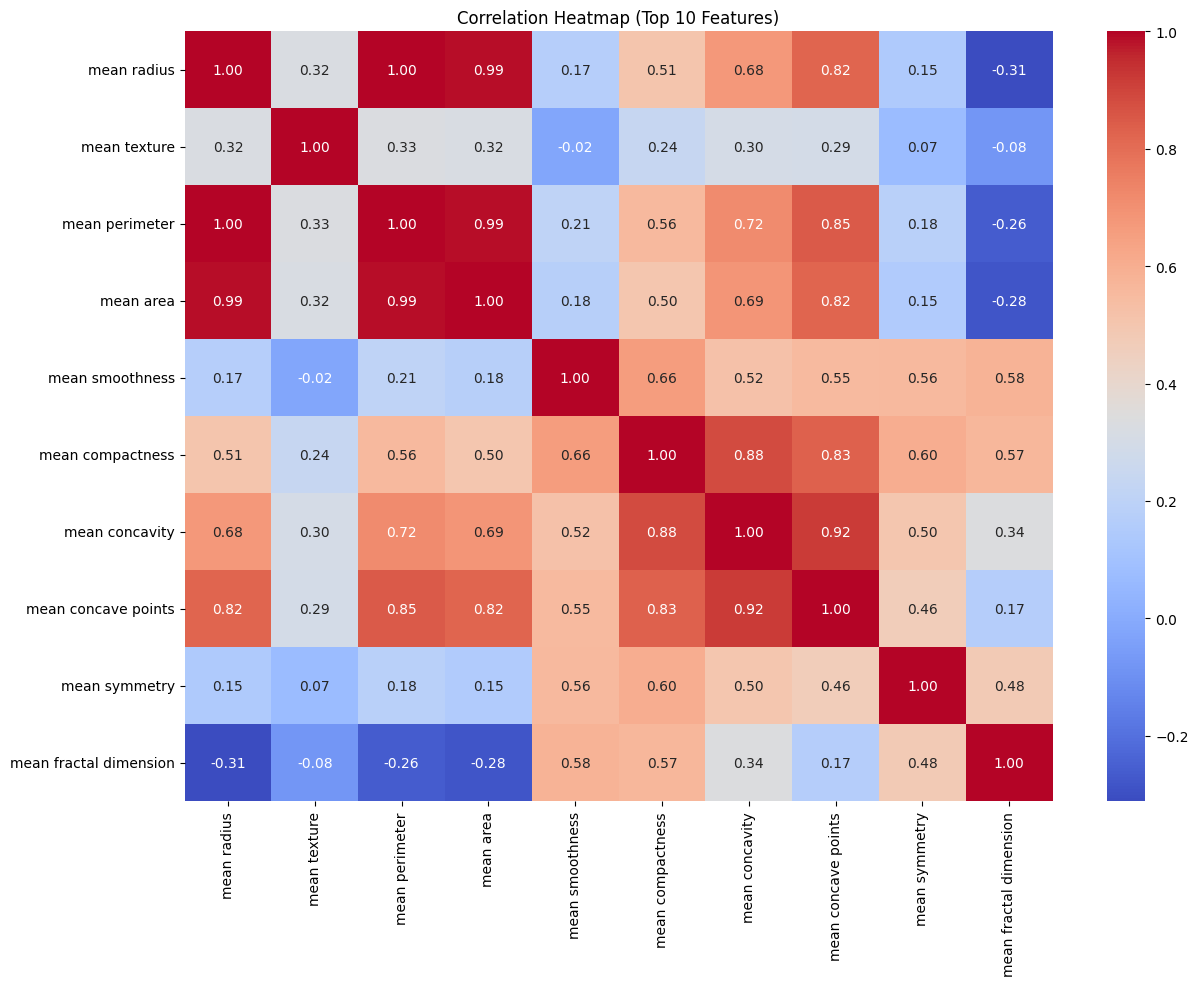

In [3]:
print(df['target'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution (0 = Malignant, 1 = Benign)')
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top 10 Features)')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000, random_state=42),
        "params": {"C": [0.01, 0.1, 1, 10]}
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [4, 6, None]}
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric='logloss'),
        "params": {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.01, 0.1]}
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}

for name, mp in param_grids.items():
    grid = GridSearchCV(mp["model"], mp["params"], cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_estimators[name] = grid.best_estimator_
    print(name, grid.best_params_, round(grid.best_score_, 4))

Logistic Regression {'C': 1} 0.9957
SVM {'C': 1, 'kernel': 'rbf'} 0.9957
Random Forest {'max_depth': 4, 'n_estimators': 200} 0.9912
XGBoost {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} 0.9936


In [6]:
results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
SVM,0.9825,0.9861,0.9861,0.9861,0.9950
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9927
XGBoost,0.9474,0.9459,0.9722,0.9589,0.9921


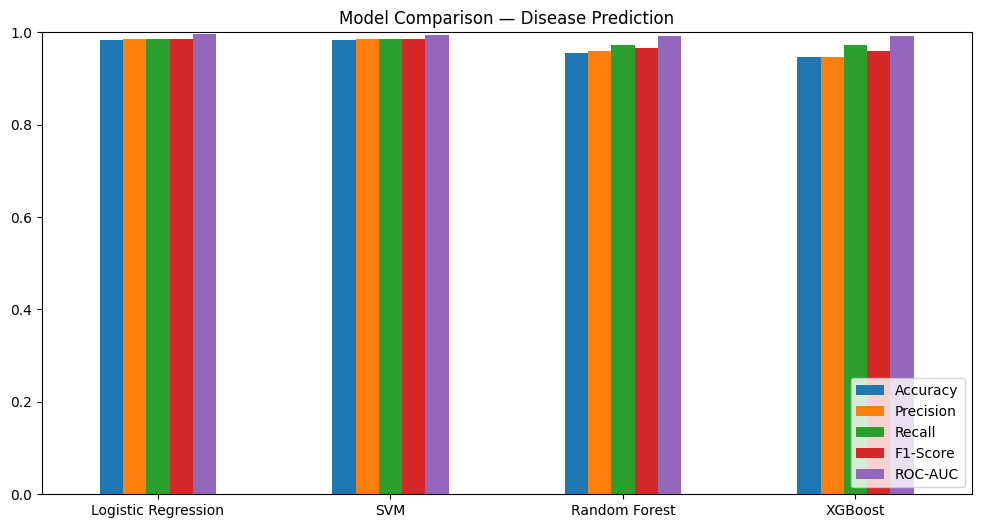

In [7]:
results_df.plot(kind='bar', figsize=(12,6))
plt.ylim(0,1)
plt.title('Model Comparison — Disease Prediction')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

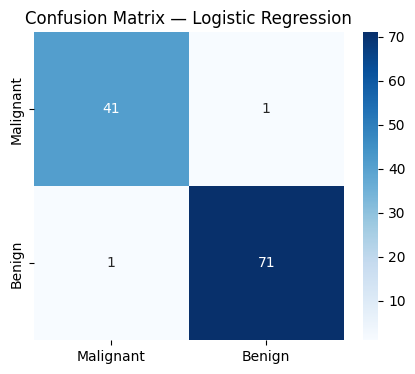

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



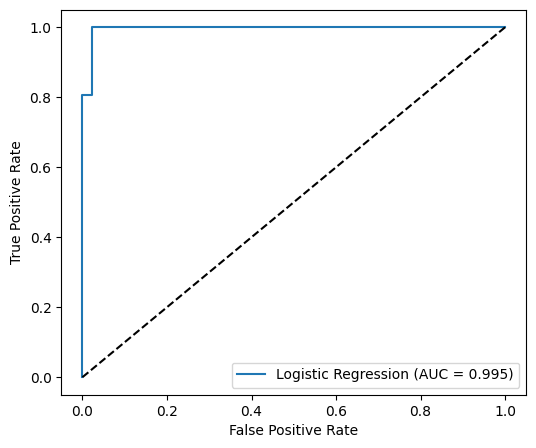

In [8]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(classification_report(y_test, y_pred_best))

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_proba_best):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [9]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(12,5))
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.show()